# 2025 DL Lab5: Object Detection on Pascal VOC

Before we start, please put **your name** and **SID** in following format: <br>
Hi I'm 陸仁賈, 314831000.

**Your Answer:**    
Hi I'm 李朋逸, 314831024

## Overview

This project focuses on object detection using the Pascal VOC dataset. 

The goal is to identify and locate various objects within images by training and evaluating detection models.
 
The dataset provides annotated images across multiple categories, making it a standard benchmark for evaluating object detection performance.


## Kaggle Competition
Kaggle is an online community of data scientists and machine learning practitioners. Kaggle allows users to find and publish datasets, explore and build models in a web-based data-science environment, work with other data scientists and machine learning engineers, and enter competitions to solve data science challenges.

This assignment use kaggle to calculate your grade.  
Please use this [**LINK**](https://www.kaggle.com/t/e86ea95cb007416a85a07d8729ac838e) to join the competition.

## Unzip Data

Unzip `dataset.zip` 

+ `vocall_test.txt` : list for the training set
+ `vocall_test.txt` : list for the validation set
+ `vocall_test.txt` : list for the test set
+ `image/` : contains all images.


The train set contains 8,218 images, the val set contains 3,823 images, and the test set contains 8,920 images.


#### You are allowed to use a **backbone model**, but only those available from the **timm package** (https://huggingface.co/timm/models).

# Import package

In [1]:
import os
import sys

# 
PROJECT_ROOT = "/workspace/DL/Lab5"

# 1. 
if os.getcwd() != PROJECT_ROOT:
    print(f"Changing CWD from {os.getcwd()} to {PROJECT_ROOT}")
    os.chdir(PROJECT_ROOT)
else:
    print(f"CWD is already correct: {PROJECT_ROOT}")

# 2. 
if PROJECT_ROOT not in sys.path:
    print(f"Adding {PROJECT_ROOT} to sys.path")
    sys.path.append(PROJECT_ROOT)

print(f"Current Working Directory: {os.getcwd()}")

CWD is already correct: /workspace/DL/Lab5
Adding /workspace/DL/Lab5 to sys.path
Current Working Directory: /workspace/DL/Lab5


In [2]:
import os
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
import numpy as np
from torch.amp import autocast, GradScaler
from src.yolo_convnext_large import getODmodel
from yolo_loss_focal import YOLOv3Loss
from src.dataset_mosaic_last import VocDetectorDataset, test_data_pipelines, train_data_pipelines,collate_fn
from src.eval_voc import evaluate
from src.config_new import GRID_SIZES, ANCHORS,YOLO_IMG_DIM
from torch.optim.lr_scheduler import CosineAnnealingLR

/workspace/DL/Lab5/src/dataset_mosaic_last.py:35: UserWarning: Argument(s) 'value' are not valid for transform Affine
  A.Affine(


In [4]:
##### hyperparameters #####
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

num_epochs = 100
batch_size = 10
learning_rate = 1e-4   

lambda_coord = 5.0
lambda_obj   = 1.0
lambda_noobj = 0.5
lambda_class = 1.0


In [5]:
from torch.utils.data import WeightedRandomSampler

# Data paths
file_root_train = './dataset/image/'
annotation_file_train = './dataset/vocall_train.txt'
file_root_val = './dataset/image/'
annotation_file_val = './dataset/vocall_val.txt'

# --- [修改點：Class-Aware Sampler] ---
def build_class_aware_sampler(dataset, target_classes, oversample_factor=1.5):
    """
    
    """
    print(f"Building Class-Aware Sampler for classes: {target_classes}")
    print(f"Oversample factor: {oversample_factor}")

    # 1. 
    # (
    target_class_indices = target_classes 
    
    # 2. 
    # (
    sample_weights = np.ones(dataset.num_samples)
    
    # 3. 
    image_indices_with_target = set()
    for cls_idx in target_class_indices:
        if cls_idx in dataset.class_img_map:
            image_indices_with_target.update(dataset.class_img_map[cls_idx])
        else:
            print(f"Warning: Class index {cls_idx} not found in dataset.class_img_map")

    # 4. 
    print(f"Found {len(image_indices_with_target)} images (out of {dataset.num_samples}) containing target classes.")
    for img_idx in image_indices_with_target:
        sample_weights[img_idx] = oversample_factor

    # 5. 
    sampler = WeightedRandomSampler(
        weights=sample_weights,
        num_samples=len(sample_weights),
        replacement=True
    )
    return sampler
# --- [修改結束] ---


# Create datasets
print('Loading datasets...')
train_dataset = VocDetectorDataset(
    root_img_dir=file_root_train,
    dataset_file=annotation_file_train,
    train=True,
    transform=train_data_pipelines,
    grid_sizes=GRID_SIZES,
    encode_target=True
)

# --- [修改點：Class-Aware Sampler] ---
# 
# (bottle, chair, pottedplant, sofa)
# (
# 
# 
TARGET_CLASSES_FOR_SAMPLING = [4, 8, 15, 17] 
train_sampler = build_class_aware_sampler(train_dataset, TARGET_CLASSES_FOR_SAMPLING, oversample_factor=1.5)
# --- [修改結束] ---

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,   # (
    collate_fn=collate_fn,
    # 
    shuffle=False,           # 
    sampler=train_sampler,   # 
    num_workers=4,
    pin_memory=True          # 
)
print(f'Loaded {len(train_dataset)} train images')

val_dataset = VocDetectorDataset(
    root_img_dir=file_root_val,
    dataset_file=annotation_file_val,
    train=False,
    transform=test_data_pipelines,
    grid_sizes=GRID_SIZES,
    encode_target=True,
)
val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    collate_fn=collate_fn,
    shuffle=False,
    num_workers=4,
    pin_memory=True
)
#for computing val maps
eval_dataset = VocDetectorDataset(
    root_img_dir=file_root_val,
    dataset_file=annotation_file_val,
    train=False,
    transform=test_data_pipelines,
    grid_sizes=GRID_SIZES,
    encode_target=False,
)
eval_loader = DataLoader(
    eval_dataset,
    batch_size=batch_size,
    collate_fn=collate_fn,
    shuffle=False,
    num_workers=4
)
print(f'Loaded {len(val_dataset)} val images')

Loading datasets...
Initializing dataset (train=True)
Building class-to-image map for Class-Aware Sampling...
Class-to-image map built.
Building Class-Aware Sampler for classes: [4, 8, 15, 17]
Oversample factor: 1.5
Found 1919 images (out of 8218) containing target classes.
Loaded 8218 train images
Initializing dataset (train=False)
Initializing dataset (train=False)
Loaded 3823 val images


## Initialization

### Only backbone model on timm is acceptable (https://huggingface.co/timm/models).
### You can modify model name in yolo class

In [5]:
load_network_path = None #'checkpoints/best_detector.pth' 
pretrained = True
model = getODmodel(pretrained=pretrained).to(device)

### Some training utils, use mix precision if valid

In [6]:
import torch
from torch.cuda.amp import GradScaler
from torch.optim.lr_scheduler import SequentialLR, LinearLR, CosineAnnealingLR
from yolo_loss_focal import YOLOv3Loss

# ---- Loss ----
criterion = YOLOv3Loss(
    box_loss_type='ciou',
    lambda_coord=lambda_coord,
    lambda_obj=lambda_obj,
    lambda_noobj=lambda_noobj,
    lambda_class=lambda_class,
    anchors=ANCHORS
).to(device)

# ---- 參數分組：Backbone 用較小 LR；Neck/Head 用原 LR ----
backbone_params, headneck_params = [], []
for n, p in model.named_parameters():
    if not p.requires_grad:
        continue
    if n.startswith("backbone"):
        backbone_params.append(p)
    else:
        headneck_params.append(p)

if len(backbone_params) == 0:
    headneck_params = list(model.parameters())

base_lr = learning_rate

optimizer = torch.optim.AdamW(
    [
        {"params": backbone_params, "lr": base_lr * 0.25},  # backbone LR 降 4 倍
        {"params": headneck_params, "lr": base_lr},         # neck/head 用 base LR
    ],
    weight_decay=5e-4,
    betas=(0.9, 0.999)
)

# ---- Scheduler：Warmup → Cosine（per-epoch step）----
warmup_epochs = 10          # 10 epoch 線性暖身
eta_min       = 1e-6        # Cosine 最低 LR

cosine = CosineAnnealingLR(
    optimizer,
    T_max=max(1, num_epochs - warmup_epochs),
    eta_min=eta_min
)

warmup = LinearLR(
    optimizer,
    start_factor=0.05,   # 從 5% LR 緩升到 100%
    end_factor=1.0,
    total_iters=warmup_epochs
)

lr_scheduler = SequentialLR(
    optimizer,
    schedulers=[warmup, cosine],
    milestones=[warmup_epochs]
)

# ---- AMP & 梯度累積設定 ----
use_amp = torch.cuda.is_available()
scaler = GradScaler(enabled=use_amp)

ACCUM_STEPS = 6  # 每 3 個 mini-batch 累積一次梯度


/tmp/ipykernel_2105778/3878600139.py:65: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler(enabled=use_amp)


### Training Loop

In [7]:
# ======= imports（缺的就補上）=======
import os, csv, math, time
import torch
import numpy as np
import logging
import random

# (請確保你在外部已定義好：
#  model, criterion, optimizer, train_loader, val_loader, eval_loader, evaluate(),
#  num_epochs, device, use_amp(bool), lr_scheduler, scaler(=GradScaler(enabled=use_amp)), ACCUM_STEPS)

# ======= 參數（可自行調整）=======
log_csv_path = 'train_log.csv'       # 訓練紀錄 CSV 檔名
log_txt_path = 'training_output.log' # 給人看的文字 log 檔名
eval_every   = 5                     # 每幾個 epoch 做一次 mAP 評估
os.makedirs('checkpoints', exist_ok=True)

# ======= [新] SOTA 增強參數（先沿用你原本的設計）=======
STAGE1_END          = 20
MIXUP_RAMP_START    = 20
MIXUP_RAMP_END      = 80
MOSAIC_RAMP_START   = 20
MOSAIC_RAMP_END     = 80
DISABLE_AUG_EPOCHS  = 20

BASE_MOSAIC_PROB    = 1.0
STRONG_MIXUP_PROB   = 0.15
STRONG_AUG_BETA     = 32.0

# ======= [新] Early Stopping 參數 =======
PATIENCE_EPOCHS = 500

# ======= [新] Multi-Scale 參數 =======
# (YOLOv5 常用 0.5x~1.5x 尺寸，步長 32。假設 640 是 1.0x)
# 這裡我們用 416 (0.65x) 到 640 (1.0x)，您也可以往上加
MULTISCALE_SIZES = [416, 448, 480, 512, 544, 576, 608, 640, 672]

# ======= Logging 設定 =======
logging.getLogger().handlers = []
logger = logging.getLogger('train_logger')
logger.setLevel(logging.INFO)
file_handler = logging.FileHandler(log_txt_path, mode='w', encoding='utf-8')
file_handler.setLevel(logging.INFO)
console_handler = logging.StreamHandler()
console_handler.setLevel(logging.INFO)
formatter = logging.Formatter('%(asctime)s - %(message)s', datefmt='%Y-%m-%d %H:%M:%S')
file_handler.setFormatter(formatter)
console_handler.setFormatter(formatter)
logger.addHandler(file_handler)
logger.addHandler(console_handler)

# ======= CSV Helper =======
def _append_csv(path, row):
    with open(path, 'a', newline='', buffering=1) as f:
        w = csv.writer(f)
        w.writerow(row)
        f.flush()
        os.fsync(f.fileno())

if not os.path.exists(log_csv_path):
    _append_csv(log_csv_path, ['epoch','iter','train_loss','box','obj','noobj','cls','val_loss','mAP','lr','time_s'])

# ======= Utils：線性工具 =======
def linear_decay(x, x0, x1):
    """在 [x0, x1] 線性從 1 降到 0（之外做 clamp）"""
    if x <= x0: return 1.0
    if x >= x1: return 0.0
    return 1.0 - (x - x0) / max(1e-9, (x1 - x0))

def get_current_aug_params(epoch, num_epochs):
    """Mosaic、MixUp 同步線性下降，最後 DISABLE_AUG_EPOCHS 關閉"""
    last_k = DISABLE_AUG_EPOCHS
    if (epoch + 1) > (num_epochs - last_k):
        return 0.0, 0.0, 0.0

    if epoch < STAGE1_END:
        return BASE_MOSAIC_PROB, STRONG_MIXUP_PROB, STRONG_AUG_BETA

    mosaic_mul = linear_decay(epoch, MOSAIC_RAMP_START, MOSAIC_RAMP_END)
    mixup_mul  = linear_decay(epoch, MIXUP_RAMP_START, MIXUP_RAMP_END)
    mosaic_prob = BASE_MOSAIC_PROB * mosaic_mul
    mixup_prob  = STRONG_MIXUP_PROB * mixup_mul
    return mosaic_prob, mixup_prob, STRONG_AUG_BETA

def freeze_bn_running_stats_in_tail_phase(model, epoch):
    """收尾期凍結 BN 的 running mean/var"""
    if epoch >= MOSAIC_RAMP_END:
        def _set_bn_eval(m):
            if isinstance(m, torch.nn.modules.batchnorm._BatchNorm):
                m.eval()
        model.apply(_set_bn_eval)

def try_set_noobj_lambda(criterion, epoch):
    """
    收尾期 noobj 權重線性增長：
    從 MOSAIC_RAMP_END 到 MOSAIC_RAMP_END+75，由 0.3 線性升到 0.7
    """
    if hasattr(criterion, 'lambda_noobj'):
        start_e = MOSAIC_RAMP_END
        end_e   = MOSAIC_RAMP_END + 20

        if epoch <= start_e:
            val = 0.5
        elif epoch >= end_e:
            val = 0.7
        else:
            progress = (epoch - start_e) / max(1, end_e - start_e)
            val = 0.5 + (0.7 - 0.5) * progress

        criterion.lambda_noobj = val

# ======= Dataset 控制 =======
try:
    train_dataset = train_loader.dataset
    logger.info("Aug control enabled: using train_loader.dataset")
    logger.info(f"Stage1: 0..{STAGE1_END} | Mosaic/MixUp linear decay: "
                f"{MOSAIC_RAMP_START}..{MOSAIC_RAMP_END} | Tail OFF last {DISABLE_AUG_EPOCHS}")
except Exception as e:
    logger.warning(f"Could not access train_loader.dataset for aug control. Error: {e}")
    train_dataset = None

# ======= 主訓練迴圈 =======
logger.info('\nStarting training...')
torch.cuda.empty_cache()
best_map = -1.0
start_time = time.time()
patience_counter = 0
PATIENCE_CYCLES = max(1, PATIENCE_EPOCHS // eval_every)

for epoch in range(num_epochs):

    # ======= [新] Multi-Scale 訓練尺寸控制 =======
    current_epoch_num = epoch + 1
    new_size = 416  # 預設

    # 根據您的「4+1」規則
    if (current_epoch_num % eval_every == 0):
        # 這是驗證 epoch (5, 10, 15...)
        # 大哥您的要求：固定 416x416
        new_size = 416
    else:
        # 這是多尺度 epoch (1-4, 6-9...)
        # 從 list 中隨機選一個尺寸
        new_size = random.choice(MULTISCALE_SIZES)
        
    try:
        # 
        # (train_dataset 
        if hasattr(train_dataset, 'set_input_dim'):
            # 呼叫 dataset_mosaic.py 裡的 set_input_dim
            train_dataset.set_input_dim(new_size) 
            
            # --- (修改點) ---
            # 
            # 
            logger.info(f"--- Epoch {current_epoch_num}: Input size set to {new_size}x{new_size} ---")
            
        else:
            logger.warning("train_dataset has no 'set_input_dim'. Multi-scale disabled.")
    except Exception as e:
        logger.error(f"Error in set_input_dim: {e}")
    # ======= [新] Multi-Scale 程式碼結束 =======

    model.train()

    # 1) 取得當前增強參數
    mosaic_prob, mixup_prob, aug_beta = get_current_aug_params(epoch, num_epochs)
    if train_dataset is not None:
        changed = (getattr(train_dataset, 'enable_mosaic', None) != (mosaic_prob > 0))
        if changed:
            logger.info(f"--- Epoch {epoch+1}: set Mosaic enable = {mosaic_prob > 0} (Prob={mosaic_prob:.2f}) ---")
        train_dataset.enable_mosaic = (mosaic_prob > 0)
        train_dataset.mosaic_prob   = mosaic_prob

    # 2) 收尾控制
    freeze_bn_running_stats_in_tail_phase(model, epoch)
    try_set_noobj_lambda(criterion, epoch)

    if ((epoch + 1) % 5 == 0) or (epoch == 0):
        logger.info(f"Current Aug Params: Mosaic={mosaic_prob:.2f}, Mixup={mixup_prob:.2f}, Beta={aug_beta}")

    logger.info(f'\nStarting epoch {epoch + 1} / {num_epochs}')

    running = {'loss':0.0, 'box':0.0, 'obj':0.0, 'noobj':0.0, 'cls':0.0}
    n_batches = 0

    # 梯度歸零放在 epoch 的開頭
    optimizer.zero_grad(set_to_none=True)

    for i, (images, target) in enumerate(train_loader):
        images = images.to(device, non_blocking=True)
        target = [t.to(device, non_blocking=True) for t in target]

        # ----- MixUp（修正後：用原始 target + 打亂後 targets_b）-----
        if mixup_prob > 0 and random.random() < mixup_prob:
            lam = np.random.beta(aug_beta, aug_beta)
            idx = torch.randperm(images.size(0), device=device)
            images = lam * images + (1 - lam) * images[idx]
            targets_b = [t[idx] for t in target]
            target = [lam * ta + (1 - lam) * tb for ta, tb in zip(target, targets_b)]

        # ----- Forward + AMP -----
        with torch.autocast(device_type="cuda", enabled=use_amp):
            pred      = model(images)
            loss_dict = criterion(pred, target)
            loss      = loss_dict['total']   # 這是「真正的」 loss 值（不除以 ACCUM_STEPS）

        if not torch.isfinite(loss):
            logger.warning(f"[Skip] Non-finite loss at epoch {epoch+1} iter {i+1}")
            optimizer.zero_grad(set_to_none=True)
            scaler.update()
            continue

        # ---- 梯度累積：backward 用縮小後的 loss ----
        loss_for_backward = loss / ACCUM_STEPS
        scaler.scale(loss_for_backward).backward()

        # 統計用的 running loss 用原始 loss
        running['loss']  += float(loss.item())
        running['box']   += float(loss_dict.get('box',   0.0))
        running['obj']   += float(loss_dict.get('obj',   0.0))
        running['noobj'] += float(loss_dict.get('noobj', 0.0))
        running['cls']   += float(loss_dict.get('cls',   0.0))
        n_batches += 1

        # ---- 每 ACCUM_STEPS 才做一次 optimizer.step() ----
        do_step = ((i + 1) % ACCUM_STEPS == 0) or ((i + 1) == len(train_loader))
        if do_step:
            # 先 unscale → clip grad → 檢查是否有限
            scaler.unscale_(optimizer)
            total_norm = torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=10.0)

            if not torch.isfinite(total_norm):
                logger.warning(f"[Skip] Non-finite grad norm at epoch {epoch+1} iter {i+1}: {total_norm}")
                optimizer.zero_grad(set_to_none=True)
                scaler.update()
                continue

            scaler.step(optimizer)
            scaler.update()
            optimizer.zero_grad(set_to_none=True)

        # 每 50 iter 記錄一次
        if i % 50 == 0:
            avg = {k: running[k]/max(n_batches,1) for k in running}
            cur_lr = sum(pg['lr'] for pg in optimizer.param_groups) / max(1, len(optimizer.param_groups))
            logger.info(
                f"Epoch [{epoch+1}/{num_epochs}], Iter [{i+1}/{len(train_loader)}], "
                f"Loss: " + ", ".join(f"{k}={avg[k]:.3f}" for k in ['loss','box','obj','noobj','cls'])
            )
            _append_csv(log_csv_path, [
                epoch+1, i+1,
                f"{avg['loss']:.6f}", f"{avg['box']:.6f}", f"{avg['obj']:.6f}",
                f"{avg['noobj']:.6f}", f"{avg['cls']:.6f}", "", "",
                f"{cur_lr:.8f}", f"{time.time()-start_time:.1f}",
            ])

    # ================== Epoch 結束（在 batch 迴圈外）==================
    if hasattr(lr_scheduler, "step"):
        lr_scheduler.step()

    # 真正生效的是 optimizer.param_groups 裡的 lr
    def _fmt_lrs(lrs):
        return " | ".join([f"group{i}={lr:.6g}" for i, lr in enumerate(lrs)])

    group_lrs = [pg['lr'] for pg in optimizer.param_groups]
    mean_lr = (sum(group_lrs) / len(group_lrs)) if group_lrs else 0.0
    logger.info(f"Learning Rates (optimizer): {_fmt_lrs(group_lrs)}")
    if hasattr(lr_scheduler, "get_last_lr"):
        sched_lrs = lr_scheduler.get_last_lr()
        logger.info(f"Learning Rates (scheduler last_lrs): {_fmt_lrs(sched_lrs)}")

    # ========== Validation ==========
    with torch.no_grad():
        model.eval()
        val_loss = 0.0
        for i, (images, target) in enumerate(val_loader):
            images = images.to(device, non_blocking=True)
            target = [t.to(device, non_blocking=True) for t in target]
            pred   = model(images)
            ldict  = criterion(pred, target)
            val_loss += float(ldict['total'].item())
        val_loss /= max(len(val_loader), 1)
        logger.info(f'Validation Loss: {val_loss:.4f}')

    avg = {k: running[k]/max(n_batches,1) for k in running} if n_batches > 0 else {
        k:0.0 for k in ['loss','box','obj','noobj','cls']
    }
    _append_csv(log_csv_path, [
        epoch+1, 'val_loss',
        f"{avg['loss']:.6f}", f"{avg['box']:.6f}", f"{avg['obj']:.6f}",
        f"{avg['noobj']:.6f}", f"{avg['cls']:.6f}", f"{val_loss:.6f}",
        "", f"{mean_lr:.8f}", f"{time.time()-start_time:.1f}",
    ])

    # ========== mAP 評估 ==========
    cur_map = float('nan')
    mAP_was_run = False
    if (epoch + 1) % eval_every == 0:
        mAP_was_run = True
        logger.info('\nEvaluating on validation set (mAP)...')
        with torch.no_grad():
            model.eval()
            val_aps = evaluate(model, eval_loader)
        cur_map = float(np.mean(val_aps)) if len(val_aps) > 0 else 0.0
        logger.info(f'Epoch {epoch+1}, mAP: {cur_map:.4f}')
        _append_csv(log_csv_path, [
            epoch+1, 'mAP_eval',
            f"{avg['loss']:.6f}", f"{avg['box']:.6f}", f"{avg['obj']:.6f}",
            f"{avg['noobj']:.6f}", f"{avg['cls']:.6f}", f"{val_loss:.6f}",
            f"{cur_map:.6f}", f"{mean_lr:.8f}", f"{time.time()-start_time:.1f}",
        ])
    else:
        logger.info(f'Skip mAP eval this epoch (run every {eval_every} epochs).')

    # ========== Early Stopping 與 Checkpoint ==========
    if mAP_was_run:
        if not math.isnan(cur_map) and cur_map > best_map:
            best_map = cur_map
            patience_counter = 0
            logger.info(f'Updating best mAP: {best_map:.5f}')
            torch.save(model.state_dict(), 'checkpoints/best_detector.pth')
        else:
            patience_counter += 1
            logger.info(f'mAP did not improve. Patience: {patience_counter}/{PATIENCE_CYCLES}')

    if (epoch + 1) in [5, 10, 20, 30, 40]:
        torch.save(model.state_dict(), f'checkpoints/detector_epoch_{epoch+1}.pth')
    torch.save(model.state_dict(), 'checkpoints/detector.pth')

    _append_csv(log_csv_path, [
        epoch+1, 'epoch_end',
        f"{avg['loss']:.6f}", f"{avg['box']:.6f}", f"{avg['obj']:.6f}",
        f"{avg['noobj']:.6f}", f"{avg['cls']:.6f}", f"{val_loss:.6f}",
        (f"{cur_map:.6f}" if not math.isnan(cur_map) else ""),
        f"{mean_lr:.8f}", f"{time.time()-start_time:.1f}",
    ])

    if mAP_was_run and patience_counter >= PATIENCE_CYCLES:
        logger.info(f"mAP has not improved for {patience_counter * eval_every} epochs (Patience={PATIENCE_EPOCHS}).")
        logger.info(f"--- Stopping training early at Epoch {epoch + 1} ---")
        break

logger.info('\nTraining complete.')

2025-11-14 19:39:02 - Aug control enabled: using train_loader.dataset
2025-11-14 19:39:02 - Stage1: 0..20 | Mosaic/MixUp linear decay: 20..80 | Tail OFF last 20
2025-11-14 19:39:02 - 
Starting training...
2025-11-14 19:39:02 - --- Epoch 1: Input size set to 608x608 ---
2025-11-14 19:39:02 - Current Aug Params: Mosaic=1.00, Mixup=0.15, Beta=32.0
2025-11-14 19:39:02 - 
Starting epoch 1 / 100
/tmp/ipykernel_2105778/3692387433.py:220: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:836.)
  running['box']   += float(loss_dict.get('box',   0.0))
2025-11-14 19:39:10 - Epoch [1/100], Iter [1/822], Loss: loss=14.125, box=0.918, obj=3.271, noobj=0.243, cls=6.140
2025-11-14 19:39:30 - Epoch [1/100], Iter [51/822], Loss: loss=13.363, box=0.886, obj=3.087, noobj=0.243, cls=5.722
2025-11-14 19:39:50 - Epoch [1/100], It

---Evaluate model on validation samples---


100%|██████████| 383/383 [01:29<00:00,  4.27it/s]


---class aeroplane ap 0.0--- (no predictions for this class)
---class bicycle ap 0.0--- (no predictions for this class)
---class bird ap 0.0--- (no predictions for this class)
---class boat ap 0.0--- (no predictions for this class)
---class bottle ap 0.0--- (no predictions for this class)
---class bus ap 0.0--- (no predictions for this class)
---class car ap 1.945525291828794e-05---
---class cat ap 0.05397212086010424---
---class chair ap 0.0--- (no predictions for this class)
---class cow ap 0.0--- (no predictions for this class)
---class diningtable ap 0.0--- (no predictions for this class)
---class dog ap 0.0---
---class horse ap 0.0--- (no predictions for this class)
---class motorbike ap 0.0--- (no predictions for this class)


2025-11-14 20:17:11 - Epoch 5, mAP: 0.0062
2025-11-14 20:17:11 - Updating best mAP: 0.00622


...

2025-11-15 07:48:04 - Epoch 95, mAP: 0.7813
2025-11-15 07:48:04 - mAP did not improve. Patience: 2/100
2025-11-15 07:48:11 - --- Epoch 96: Input size set to 448x448 ---
2025-11-15 07:48:11 - 
Starting epoch 96 / 100
2025-11-15 07:48:12 - Epoch [96/100], Iter [1/822], Loss: loss=0.459, box=0.083, obj=0.005, noobj=0.048, cls=0.007
2025-11-15 07:48:33 - Epoch [96/100], Iter [51/822], Loss: loss=0.355, box=0.064, obj=0.006, noobj=0.031, cls=0.006
2025-11-15 07:48:55 - Epoch [96/100], Iter [101/822], Loss: loss=0.354, box=0.064, obj=0.007, noobj=0.032, cls=0.008
2025-11-15 07:49:16 - Epoch [96/100], Iter [151/822], Loss: loss=0.364, box=0.065, obj=0.006, noobj=0.032, cls=0.013
2025-11-15 07:49:37 - Epoch [96/100], Iter [201/822], Loss: loss=0.362, box=0.064, obj=0.006, noobj=0.032, cls=0.013
2025-11-15 07:49:58 - Epoch [96/100], Iter [251/822], Loss: loss=0.366, box=0.065, obj=0.007, noobj=0.033, cls=0.012
2025-11-15 07:50:20 - Epoch [96/100], Iter [301/822], Loss: loss=0.365, box=0.065, ob

---Evaluate model on validation samples---


100%|██████████| 383/383 [01:30<00:00,  4.24it/s]


---class aeroplane ap 0.8219895190306252---
---class bicycle ap 0.8232463722931541---
---class bird ap 0.8398012275801308---
---class boat ap 0.6575358316165089---
---class bottle ap 0.533541377066677---
---class bus ap 0.8421916350353016---
---class car ap 0.8285016147041269---
---class cat ap 0.9616110256742956---
---class chair ap 0.5719910954214267---
---class cow ap 0.8427538512633821---
---class diningtable ap 0.682435862979197---
---class dog ap 0.9163241605678858---
---class horse ap 0.8904663473402886---
---class motorbike ap 0.8417278938158772---
---class person ap 0.8184678427311708---
---class pottedplant ap 0.5473984394571166---
---class sheep ap 0.8123760090806887---
---class sofa ap 0.6676608878576376---
---class train ap 0.9000323414279945---
---class tvmonitor ap 0.8278392062601105---
---map 0.7813946270601797---


2025-11-15 08:26:29 - Epoch 100, mAP: 0.7814
2025-11-15 08:26:29 - mAP did not improve. Patience: 3/100
2025-11-15 08:26:36 - 
Training complete.


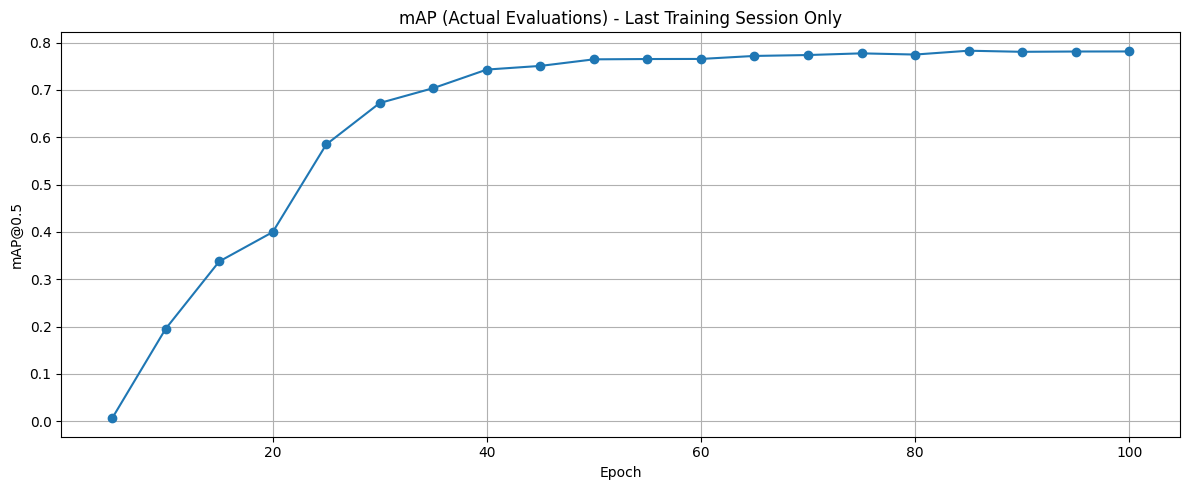

Final mAP (last session): 0.7814 (at Epoch 100)


In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import sys
import numpy as np

cols = ['epoch','iter','train_loss','box','obj','noobj','cls','val_loss','mAP','lr','time_s']
try:
    df = pd.read_csv('train_log.csv', header=None, names=cols)
    if df.empty:
        print("train_log.csv is empty."); sys.exit()
except FileNotFoundError:
    print("train_log.csv not found."); sys.exit()
except pd.errors.EmptyDataError:
    print("train_log.csv is empty."); sys.exit()

# 轉數值（有些列是字串）
df['epoch']  = pd.to_numeric(df['epoch'], errors='coerce')
df['mAP']    = pd.to_numeric(df['mAP'], errors='coerce')
df['time_s'] = pd.to_numeric(df['time_s'], errors='coerce')

# ---- 只取最後一個訓練 session ----
def slice_last_session(df: pd.DataFrame) -> pd.DataFrame:
    # 優先用 time_s：找到最後一次 time_s 從大跳小（重置）的分段點
    if df['time_s'].notna().any():
        ts = df['time_s'].fillna(-1e9).values
        reset_idx = np.where(ts[1:] < ts[:-1])[0]
        start = (reset_idx[-1] + 1) if len(reset_idx) else 0
        return df.iloc[start:].copy()

    # 後備：用 epoch 回繞
    ep = df['epoch'].fillna(-1).values
    reset_idx = np.where(ep[1:] < ep[:-1])[0]
    start = (reset_idx[-1] + 1) if len(reset_idx) else 0
    return df.iloc[start:].copy()

df_last = slice_last_session(df)

# 只抓本 session 的 mAP 評估列
me = df_last[df_last['iter'].astype(str) == 'mAP_eval'].copy()
me = me.dropna(subset=['epoch','mAP'])

# 同 epoch 可能多次評估，取最大值
map_plot_data = me.groupby('epoch')['mAP'].max().sort_index()

if map_plot_data.empty:
    print("No 'mAP_eval' data found in the last session."); sys.exit()

plt.figure(figsize=(12, 5))
plt.plot(map_plot_data.index, map_plot_data.values, marker='o', linestyle='-')
plt.title('mAP (Actual Evaluations) - Last Training Session Only')
plt.xlabel('Epoch')
plt.ylabel('mAP@0.5')
plt.grid(True)
plt.tight_layout()
plt.show()

final_epoch = int(map_plot_data.index[-1])
final_map = float(map_plot_data.iloc[-1])
print(f"Final mAP (last session): {final_map:.4f} (at Epoch {final_epoch})")


# Kaggle submission

### Predict Result

Predict the results based on testing set. Upload to [Kaggle](https://www.kaggle.com/t/e86ea95cb007416a85a07d8729ac838e).

**How to upload**

1. Click the folder icon in the left hand side of Colab.
2. Right click "result.csv". Select "Download"
3. To kaggle. Click "Submit Predictions"
4. Upload the result.csv
5. System will automaticlaly calculate the accuracy of 50% dataset and publish this result to leaderboard.


In [9]:
!python predict_test.py

/workspace/DL/Lab5/src/dataset_mosaic.py:35: UserWarning: Argument(s) 'value' are not valid for transform Affine
  A.Affine(
Running inference on cuda, TTA mode: hflip
Predictions written to result.csv


In [6]:
# ==== 你可調整的路徑 ====
VAL_LIST = "dataset/vocall_val.txt"   # 你的驗證 split（檔名 + 標註）
IMG_DIR  = "dataset/image"            # 影像所在資料夾
WEIGHTS  = "checkpoints/best_detector.pth"

# 產出檔
VAL_IDS_TXT      = "val_ids.txt"       # 僅包含檔名，給 predict_test.py --test-list 用
VAL_SOLUTION_CSV = "val_solution.csv"  # 本地 Kaggle 評分用的 GT CSV
PRED_NONE_CSV    = "preds_tta_none.csv"
PRED_HFLIP_CSV   = "preds_tta_hflip.csv"

CONF_THRES = 0.01
NMS_THRES  = 0.4
DEVICE     = "auto"

# ==== VOC 類別 ====
VOC_CLASSES = (
    "aeroplane","bicycle","bird","boat","bottle",
    "bus","car","cat","chair","cow",
    "diningtable","dog","horse","motorbike","person",
    "pottedplant","sheep","sofa","train","tvmonitor"
)

# ---- 解析一行 split：回傳 (img_name, boxes)
# boxes: List[[class_name, score(=1.0), x1, y1, x2, y2]]
def parse_split_line(line: str):
    """
    支援兩種格式：
    1) '000123.jpg'                            -> (name, [])
    2) '000123.jpg x1 y1 x2 y2 cls x1 y1 ...' -> (name, [[cls_name,1.0,x1,y1,x2,y2], ...])
    """
    parts = line.strip().split()
    if not parts:
        return None, []

    name = parts[0]
    nums = parts[1:]

    boxes = []
    if nums:
        if len(nums) % 5 != 0:
            raise ValueError(f"標註欄位數不是 5 的倍數：{line[:120]}...")
        # 以 5 個一組：x1 y1 x2 y2 cls
        for i in range(0, len(nums), 5):
            x1 = float(nums[i+0]); y1 = float(nums[i+1])
            x2 = float(nums[i+2]); y2 = float(nums[i+3])
            cls_id = int(nums[i+4])
            # 假設是 0-based（從你的例子 '14' 對應 person 來看是 0-based）
            if not (0 <= cls_id < len(VOC_CLASSES)):
                raise ValueError(f"cls_id 超界: {cls_id}（行：{line[:120]}）")
            cls_name = VOC_CLASSES[cls_id]
            boxes.append([cls_name, 1.0, x1, y1, x2, y2])
    return name, boxes

# ---- 讀取驗證清單並快速檢查 ----
import os

assert os.path.exists(VAL_LIST), f"VAL_LIST 不存在: {VAL_LIST}"
assert os.path.isdir(IMG_DIR),   f"找不到影像資料夾: {IMG_DIR}"

with open(VAL_LIST) as f:
    raw_lines = [l for l in f if l.strip()]

parsed = []
for l in raw_lines:
    nm, bx = parse_split_line(l)
    if nm is not None:
        parsed.append((nm, bx))

print(f"[OK] 讀到 {len(parsed)} 行。前 3 筆解析預覽：")
for i in range(min(3, len(parsed))):
    print("  ", parsed[i])

# 檢查是否能在 IMG_DIR 找到對應影像
missing = [nm for (nm, _) in parsed if not os.path.exists(os.path.join(IMG_DIR, nm))]
print(f"[檢查] 找不到影像檔數量：{len(missing)}")
if missing[:5]:
    print("  範例：", missing[:5])


[OK] 讀到 3823 行。前 3 筆解析預覽：
   ('000684.jpg', [['chair', 1.0, 124.0, 196.0, 253.0, 305.0], ['chair', 1.0, 2.0, 305.0, 67.0, 345.0], ['person', 1.0, 52.0, 112.0, 91.0, 183.0], ['person', 1.0, 1.0, 196.0, 118.0, 322.0], ['bottle', 1.0, 54.0, 171.0, 77.0, 222.0], ['person', 1.0, 77.0, 101.0, 241.0, 314.0], ['person', 1.0, 217.0, 49.0, 294.0, 304.0], ['person', 1.0, 285.0, 22.0, 361.0, 366.0], ['person', 1.0, 297.0, 3.0, 375.0, 369.0]])
   ('009305.jpg', [['bicycle', 1.0, 76.0, 74.0, 401.0, 318.0]])
   ('2008_007086.jpg', [['cat', 1.0, 155.0, 69.0, 494.0, 285.0], ['cat', 1.0, 10.0, 16.0, 304.0, 248.0]])
[檢查] 找不到影像檔數量：0


In [7]:
import csv, os

# 輸出 val_ids.txt：只有檔名，給 predict_test.py --test-list 使用
with open(VAL_IDS_TXT, "w") as f:
    for nm, _ in parsed:
        f.write(nm + "\n")
print(f"[OK] 輸出 {VAL_IDS_TXT}（{len(parsed)} 筆）")

# 輸出 val_solution.csv：用 split 內的 (x1,y1,x2,y2,cls_id) 直接當 GT
with open(VAL_SOLUTION_CSV, "w", newline="") as f:
    w = csv.writer(f)
    w.writerow(["id", "prediction_list"])
    for nm, boxes in parsed:
        # boxes 已經是 [[class_name,1.0,x1,y1,x2,y2], ...]
        w.writerow([nm, str(boxes)])
print(f"[OK] 輸出 {VAL_SOLUTION_CSV}（{len(parsed)} 筆）")

# 再次抽樣檢查
import random
samp = random.sample(parsed, min(3, len(parsed)))
print("[抽樣檢查 val_solution 範例]")
for nm, boxes in samp:
    print(" ", nm, "->", boxes[:2], ("... (共%d框)" % len(boxes)) if len(boxes)>2 else "")


[OK] 輸出 val_ids.txt（3823 筆）
[OK] 輸出 val_solution.csv（3823 筆）
[抽樣檢查 val_solution 範例]
  2009_004518.jpg -> [['car', 1.0, 325.0, 57.0, 340.0, 68.0], ['car', 1.0, 290.0, 56.0, 306.0, 65.0]] ... (共15框)
  006712.jpg -> [['pottedplant', 1.0, 38.0, 42.0, 288.0, 444.0]] 
  2008_004002.jpg -> [['person', 1.0, 110.0, 109.0, 345.0, 375.0], ['pottedplant', 1.0, 287.0, 59.0, 500.0, 344.0]] ... (共3框)


In [8]:
import subprocess, shlex, ast, numpy as np, pandas as pd
from collections import defaultdict

# ---- 跑推論（兩版 TTA）
def run_predict(tta_mode, output_csv):
    cmd = f"""
    python predict_test.py \
      --weights {shlex.quote(WEIGHTS)} \
      --test-list {shlex.quote(VAL_IDS_TXT)} \
      --images-dir {shlex.quote(IMG_DIR)} \
      --output {shlex.quote(output_csv)} \
      --conf-thres {CONF_THRES} \
      --nms-thres {NMS_THRES} \
      --tta {tta_mode} \
      --device {DEVICE}
    """
    print("[RUN]", cmd)
    ret = subprocess.run(cmd, shell=True)
    if ret.returncode != 0:
        raise RuntimeError(f"predict_test.py failed (rc={ret.returncode})")
    print(f"[OK] {tta_mode} -> {output_csv}")

run_predict("none",  PRED_NONE_CSV)
run_predict("hflip", PRED_HFLIP_CSV)

# ---- 你的 Kaggle score()（簡化版，沿用你先前給的邏輯）
CLASSES = VOC_CLASSES
CLASS_TO_INDEX = {c:i for i,c in enumerate(CLASSES)}

def score(solution: pd.DataFrame, submission: pd.DataFrame, row_id_column_name: str) -> float:
    IOU_THRESHOLD = 0.5

    def _decode_prediction_list(value: object):
        if value is None or (isinstance(value, float) and np.isnan(value)):
            return []
        if isinstance(value, str):
            s = value.strip()
            if not s:
                return []
            data = ast.literal_eval(s)
        else:
            data = value
        parsed = []
        for det in data:
            cls, sc, x1, y1, x2, y2 = det
            parsed.append((CLASS_TO_INDEX[cls], float(sc), np.array([float(x1), float(y1), float(x2), float(y2)], dtype=np.float32)))
        return parsed

    def _parse_ground_truth(series: pd.Series):
        gt_boxes = defaultdict(list)
        counts = np.zeros(len(CLASSES), dtype=np.int64)
        for img_id, v in series.items():
            for cls_idx, _, box in _decode_prediction_list(v):
                gt_boxes[(img_id, cls_idx)].append(box); counts[cls_idx]+=1
        return gt_boxes, counts

    def _parse_predictions(series: pd.Series):
        preds = defaultdict(list)
        for img_id, v in series.items():
            for cls_idx, sc, box in _decode_prediction_list(v):
                preds[cls_idx].append((img_id, sc, box))
        return preds

    def _iou(a, b):
        ix1, iy1 = max(a[0], b[0]), max(a[1], b[1])
        ix2, iy2 = min(a[2], b[2]), min(a[3], b[3])
        iw, ih = max(ix2-ix1+1.0,0.0), max(iy2-iy1+1.0,0.0)
        inter = iw*ih
        ua = (a[2]-a[0]+1.0)*(a[3]-a[1]+1.0)
        ub = (b[2]-b[0]+1.0)*(b[3]-b[1]+1.0)
        u = ua+ub-inter
        return 0.0 if u<=0 else float(inter/u)

    def _voc_ap(rec, prec):
        mrec = np.concatenate(([0.0], rec, [1.0]))
        mpre = np.concatenate(([0.0], prec, [0.0]))
        for i in range(mpre.size-1, 0, -1):
            mpre[i-1] = max(mpre[i-1], mpre[i])
        idx = np.where(mrec[1:] != mrec[:-1])[0]
        return float(np.sum((mrec[idx+1]-mrec[idx]) * mpre[idx+1]))

    sol = solution.set_index("id")
    sub = submission.set_index("id")
    # 對齊行
    sub = sub.loc[sol.index]

    gt_boxes, gt_counts = _parse_ground_truth(sol["prediction_list"])
    pred_by_cls = _parse_predictions(sub["prediction_list"])

    aps = []
    for ci in range(len(CLASSES)):
        num_gt = gt_counts[ci]
        preds = pred_by_cls[ci]
        if num_gt == 0:
            continue
        if not preds:
            aps.append(0.0); continue
        preds = sorted(preds, key=lambda x: x[1], reverse=True)
        tp = np.zeros(len(preds), dtype=np.float32)
        fp = np.zeros(len(preds), dtype=np.float32)
        used = {k: np.zeros(len(v), dtype=bool) for k,v in gt_boxes.items() if k[1]==ci}
        for i,(img_id, sc, box) in enumerate(preds):
            key = (img_id, ci)
            gts = gt_boxes.get(key, [])
            if gts:
                ious = np.array([_iou(box, g) for g in gts], dtype=np.float32)
                j = int(ious.argmax()); best = float(ious[j])
                if best >= IOU_THRESHOLD and not used[key][j]:
                    tp[i]=1.0; used[key][j]=True
                else:
                    fp[i]=1.0
            else:
                fp[i]=1.0
        tp = np.cumsum(tp); fp = np.cumsum(fp)
        rec = tp / num_gt
        prec = tp / np.maximum(tp+fp, np.finfo(np.float64).eps)
        aps.append(_voc_ap(rec, prec))
    return float(np.mean(aps)) if aps else 0.0

# ---- 打分
sol = pd.read_csv(VAL_SOLUTION_CSV)
pred_none  = pd.read_csv(PRED_NONE_CSV)
pred_hflip = pd.read_csv(PRED_HFLIP_CSV)

m_none  = score(sol, pred_none, "id")
m_hflip = score(sol, pred_hflip, "id")

print(f"mAP (TTA none)  : {m_none:.4f}")
print(f"mAP (TTA hflip) : {m_hflip:.4f}")
print(f"Delta (hflip - none): {m_hflip - m_none:+.4f}")


[RUN] 
    python predict_test.py       --weights checkpoints/best_detector.pth       --test-list val_ids.txt       --images-dir dataset/image       --output preds_tta_none.csv       --conf-thres 0.01       --nms-thres 0.4       --tta none       --device auto
    


/workspace/DL/Lab5/src/dataset_mosaic.py:35: UserWarning: Argument(s) 'value' are not valid for transform Affine
  A.Affine(


Running inference on cuda, TTA mode: none
Predictions written to preds_tta_none.csv
[OK] none -> preds_tta_none.csv
[RUN] 
    python predict_test.py       --weights checkpoints/best_detector.pth       --test-list val_ids.txt       --images-dir dataset/image       --output preds_tta_hflip.csv       --conf-thres 0.01       --nms-thres 0.4       --tta hflip       --device auto
    


/workspace/DL/Lab5/src/dataset_mosaic.py:35: UserWarning: Argument(s) 'value' are not valid for transform Affine
  A.Affine(


Running inference on cuda, TTA mode: hflip
Predictions written to preds_tta_hflip.csv
[OK] hflip -> preds_tta_hflip.csv
mAP (TTA none)  : 0.7935
mAP (TTA hflip) : 0.8024
Delta (hflip - none): +0.0089


In [9]:
# === Fast WBF merge (Jupyter-friendly) ===
import ast
import time
import numpy as np
import pandas as pd
from collections import defaultdict
from tqdm import tqdm
import multiprocessing as mp

# ---- Tunables ----
IOU_THR = 0.55        # WBF 聚類 IoU
MIN_SCORE = 0.01      # 先過一個較低分數門檻，避免爆量
TOPK_PER_CLASS = 200  # 每圖每類別最多保留 K 個框進 WBF
N_PROCS = max(1, mp.cpu_count() - 1)  # 多進程數
USE_MP = True         # True=多進程；卡住就切 False 先跑單進程確認

def parse_predlist(s):
    if not isinstance(s, str) or not s.strip():
        return []
    try:
        data = ast.literal_eval(s)
    except Exception:
        return []
    out=[]
    for det in data:
        if isinstance(det, (list, tuple)) and len(det)==6:
            cls, sc, x1, y1, x2, y2 = det
            try:
                sc = float(sc)
                if sc < MIN_SCORE:
                    continue
                out.append([cls, sc, float(x1), float(y1), float(x2), float(y2)])
            except Exception:
                pass
    return out

def nms_per_class(dets, iou_thr=0.7):
    if not dets:
        return dets
    dets = sorted(dets, key=lambda x: x[1], reverse=True)
    boxes = np.array([d[2:] for d in dets], dtype=np.float32)
    scores = np.array([d[1] for d in dets], dtype=np.float32)
    keep_idx = []

    x1,y1,x2,y2 = boxes[:,0], boxes[:,1], boxes[:,2], boxes[:,3]
    areas = (x2-x1)*(y2-y1)
    order = scores.argsort()[::-1]

    while order.size > 0:
        i = order[0]
        keep_idx.append(i)
        if order.size == 1:
            break
        xx1 = np.maximum(x1[i], x1[order[1:]])
        yy1 = np.maximum(y1[i], y1[order[1:]])
        xx2 = np.minimum(x2[i], x2[order[1:]])
        yy2 = np.minimum(y2[i], y2[order[1:]])
        w = np.maximum(0.0, xx2-xx1)
        h = np.maximum(0.0, yy2-yy1)
        inter = w*h
        iou = inter / (areas[i] + areas[order[1:]] - inter + 1e-9)
        order = order[1:][iou < iou_thr]
    return [dets[i] for i in keep_idx]

def wbf_per_class_fast(dets_cls, iou_thr=0.55):
    if not dets_cls:
        return []
    dets_cls = sorted(dets_cls, key=lambda x: x[1], reverse=True)[:TOPK_PER_CLASS]
    boxes = np.array([d[2:] for d in dets_cls], dtype=np.float32)
    scores = np.array([d[1] for d in dets_cls], dtype=np.float32)
    used = np.zeros(len(dets_cls), dtype=bool)
    merged = []
    for i in range(len(dets_cls)):
        if used[i]:
            continue
        used[i] = True
        base = boxes[i]
        # 向量化 IoU
        xx1 = np.maximum(base[0], boxes[:,0])
        yy1 = np.maximum(base[1], boxes[:,1])
        xx2 = np.minimum(base[2], boxes[:,2])
        yy2 = np.minimum(base[3], boxes[:,3])
        w = np.maximum(0.0, xx2-xx1)
        h = np.maximum(0.0, yy2-yy1)
        inter = w*h
        area_i = (base[2]-base[0])*(base[3]-base[1])
        area_all = (boxes[:,2]-boxes[:,0])*(boxes[:,3]-boxes[:,1])
        iou = inter / (area_i + area_all - inter + 1e-9)

        cluster_idx = np.where((iou >= iou_thr) & (~used))[0]
        idx = np.concatenate(([i], cluster_idx))
        used[idx] = True

        ws = scores[idx][:,None]
        b  = boxes[idx]
        box = (b * ws).sum(axis=0) / max(ws.sum(), 1e-9)
        score = float(scores[idx].max())  # 也可改 np.mean(scores[idx])
        merged.append([dets_cls[0][0], score, *box.tolist()])
    return merged

def merge_one_image(args):
    img_id, s1, s2 = args
    dets = []
    dets += parse_predlist(s1)
    dets += parse_predlist(s2)
    if not dets:
        return [img_id, "[]"]

    # by class
    from collections import defaultdict
    by_cls = defaultdict(list)
    for d in dets:
        by_cls[d[0]].append(d)

    merged_all = []
    for cls, arr in by_cls.items():
        # 先簡單 NMS 壓密度
        arr = nms_per_class(arr, iou_thr=0.7)
        # 再 WBF（TopK 保護）
        merged_all += wbf_per_class_fast(arr, iou_thr=IOU_THR)

    return [img_id, str(merged_all)]

# 讀兩份 CSV
p1 = pd.read_csv("preds_tta_none.csv").set_index("id")
p2 = pd.read_csv("preds_tta_hflip.csv").set_index("id")
assert set(p1.index) == set(p2.index)
ids = p1.index.tolist()

tasks = [(img_id, p1.loc[img_id, "prediction_list"], p2.loc[img_id, "prediction_list"]) for img_id in ids]

start = time.time()
rows = []

if USE_MP:
    # 在 notebook 上用 'fork' 會比較順（Linux）。如果卡住，就把 USE_MP=False 改單進程先跑。
    ctx = mp.get_context("fork") if hasattr(mp, "get_context") else mp
    with ctx.Pool(processes=N_PROCS) as pool:
        for out in tqdm(pool.imap_unordered(merge_one_image, tasks, chunksize=16), total=len(tasks)):
            rows.append(out)
else:
    for t in tqdm(tasks):
        rows.append(merge_one_image(t))

sec = time.time() - start
print(f"[TIME] {sec:.1f}s  ({len(tasks)/max(sec,1):.1f} img/s, procs={N_PROCS}, MP={USE_MP})")

out_df = pd.DataFrame(rows, columns=["id","prediction_list"]).sort_values("id")
out_df.to_csv("preds_wbf.csv", index=False)
print("[OK] wrote preds_wbf.csv")


100%|██████████| 3823/3823 [00:00<00:00, 6377.39it/s]


[TIME] 0.8s  (3823.0 img/s, procs=23, MP=True)
[OK] wrote preds_wbf.csv


In [10]:
import os

cands = []
for root, _, files in os.walk(".", topdown=True):
    for fn in files:
        if fn.lower().endswith(".csv") and "val_solution" in fn.lower():
            p = os.path.join(root, fn)
            cands.append(p)

print("Found:", len(cands))
for p in sorted(cands, key=lambda x: os.path.getsize(x), reverse=True):
    print(p, os.path.getsize(p))


Found: 1
./val_solution.csv 548625


In [11]:
import os
import pandas as pd
import numpy as np

# ====== 1) 設定 GT 檔路徑（請改這行）======
solution_csv = "./val_solution.csv"   # 例如改成 "./val/val_solution.csv"

# ====== 2) 這段是你的 Kaggle 計分程式（原樣）======
import ast
from collections import defaultdict
from typing import Dict, Iterable, List, Optional, Sequence, Tuple

CLASSES: Tuple[str, ...] = (
    "aeroplane","bicycle","bird","boat","bottle",
    "bus","car","cat","chair","cow",
    "diningtable","dog","horse","motorbike","person",
    "pottedplant","sheep","sofa","train","tvmonitor",
)
CLASS_TO_INDEX: Dict[str, int] = {cls: idx for idx, cls in enumerate(CLASSES)}
IOU_THRESHOLD: float = 0.5

class ParticipantVisibleError(Exception):
    pass

def _validate_columns(solution: pd.DataFrame, submission: pd.DataFrame, row_id_column_name: str) -> None:
    required_solution_cols = {row_id_column_name, "prediction_list"}
    required_submission_cols = {row_id_column_name, "prediction_list"}

    missing_sol = required_solution_cols.difference(solution.columns)
    if missing_sol:
        raise ParticipantVisibleError(f"Solution file missing columns: {sorted(missing_sol)}")

    missing_sub = required_submission_cols.difference(submission.columns)
    if missing_sub:
        raise ParticipantVisibleError(f"Submission file missing columns: {sorted(missing_sub)}")

def _decode_prediction_list(value: object, *, context: str) -> List[Tuple[int, float, np.ndarray]]:
    if value is None or (isinstance(value, float) and np.isnan(value)):
        return []
    if isinstance(value, str):
        stripped = value.strip()
        if not stripped:
            return []
        try:
            data = ast.literal_eval(stripped)
        except (SyntaxError, ValueError):
            raise ParticipantVisibleError(f"Could not parse prediction_list for {context}.")
    else:
        data = value

    if data is None or data == "":
        return []
    if not isinstance(data, Sequence):
        raise ParticipantVisibleError("prediction_list must be a sequence of detections.")

    parsed: List[Tuple[int, float, np.ndarray]] = []
    for det in data:
        if not isinstance(det, Sequence) or len(det) != 6:
            raise ParticipantVisibleError("Each detection must be [class_name, score, xmin, ymin, xmax, ymax].")
        class_name, score, xmin, ymin, xmax, ymax = det

        if class_name not in CLASS_TO_INDEX:
            raise ParticipantVisibleError(f"Unknown class '{class_name}'.")

        try:
            score_f = float(score)
            xmin_f = float(xmin)
            ymin_f = float(ymin)
            xmax_f = float(xmax)
            ymax_f = float(ymax)
        except (TypeError, ValueError):
            raise ParticipantVisibleError("Bounding box coordinates and scores must be numeric.")

        if xmax_f < xmin_f or ymax_f < ymin_f:
            raise ParticipantVisibleError("Bounding box has negative area.")

        box = np.array([xmin_f, ymin_f, xmax_f, ymax_f], dtype=np.float32)
        parsed.append((CLASS_TO_INDEX[class_name], score_f, box))

    return parsed

def _parse_ground_truth(series: pd.Series) -> Tuple[Dict[Tuple[str, int], List[np.ndarray]], np.ndarray]:
    gt_boxes: Dict[Tuple[str, int], List[np.ndarray]] = defaultdict(list)
    class_counts = np.zeros(len(CLASSES), dtype=np.int64)

    for image_id, value in series.items():
        entries = _decode_prediction_list(value, context="solution")
        for class_idx, _, box in entries:
            gt_boxes[(image_id, class_idx)].append(box)
            class_counts[class_idx] += 1

    return gt_boxes, class_counts

def _parse_predictions(series: pd.Series) -> Dict[int, List[Tuple[str, float, np.ndarray]]]:
    preds: Dict[int, List[Tuple[str, float, np.ndarray]]] = defaultdict(list)
    for image_id, value in series.items():
        entries = _decode_prediction_list(value, context="submission")
        for class_idx, score, box in entries:
            if score < 0 or not np.isfinite(score):
                raise ParticipantVisibleError(f"Invalid confidence score {score} for image {image_id}.")
            preds[class_idx].append((image_id, float(score), box))
    return preds

def _bbox_iou(box_a: np.ndarray, box_b: np.ndarray) -> float:
    ixmin = max(box_a[0], box_b[0])
    iymin = max(box_a[1], box_b[1])
    ixmax = min(box_a[2], box_b[2])
    iymax = min(box_a[3], box_b[3])

    iw = max(ixmax - ixmin + 1.0, 0.0)
    ih = max(iymax - iymin + 1.0, 0.0)
    inter = iw * ih

    area_a = (box_a[2] - box_a[0] + 1.0) * (box_a[3] - box_a[1] + 1.0)
    area_b = (box_b[2] - box_b[0] + 1.0) * (box_b[3] - box_b[1] + 1.0)

    union = area_a + area_b - inter
    if union <= 0.0:
        return 0.0
    return float(inter / union)

def _voc_ap(recall: np.ndarray, precision: np.ndarray) -> float:
    mrec = np.concatenate(([0.0], recall, [1.0]))
    mpre = np.concatenate(([0.0], precision, [0.0]))

    for i in range(mpre.size - 1, 0, -1):
        mpre[i - 1] = np.maximum(mpre[i - 1], mpre[i])

    idx = np.where(mrec[1:] != mrec[:-1])[0]
    ap = np.sum((mrec[idx + 1] - mrec[idx]) * mpre[idx + 1])
    return float(ap)

def _average_precision_for_class(
    class_idx: int,
    gt_boxes: Dict[Tuple[str, int], List[np.ndarray]],
    num_gt: int,
    predictions: Sequence[Tuple[str, float, np.ndarray]],
) -> Optional[float]:
    if num_gt == 0:
        return None
    if not predictions:
        return 0.0

    sorted_preds = sorted(predictions, key=lambda x: x[1], reverse=True)
    tp = np.zeros(len(sorted_preds), dtype=np.float32)
    fp = np.zeros(len(sorted_preds), dtype=np.float32)

    gt_used: Dict[Tuple[str, int], np.ndarray] = {
        key: np.zeros(len(boxes), dtype=bool) for key, boxes in gt_boxes.items() if key[1] == class_idx
    }

    for i, (image_id, score, box) in enumerate(sorted_preds):
        key = (image_id, class_idx)
        gts = gt_boxes.get(key, [])
        if gts:
            overlaps = np.array([_bbox_iou(box, gt_box) for gt_box in gts], dtype=np.float32)
            best = overlaps.argmax()
            best_iou = overlaps[best]
            if best_iou >= IOU_THRESHOLD and not gt_used[key][best]:
                tp[i] = 1.0
                gt_used[key][best] = True
            else:
                fp[i] = 1.0
        else:
            fp[i] = 1.0

    tp = np.cumsum(tp)
    fp = np.cumsum(fp)

    recall = tp / num_gt
    precision = tp / np.maximum(tp + fp, np.finfo(np.float64).eps)

    return _voc_ap(recall, precision)

def score(solution: pd.DataFrame, submission: pd.DataFrame, row_id_column_name: str) -> float:
    _validate_columns(solution, submission, row_id_column_name)

    sol = solution.set_index(row_id_column_name)
    sub = submission.set_index(row_id_column_name)

    if sol.index.has_duplicates:
        raise ParticipantVisibleError("Solution contains duplicated image ids.")
    if sub.index.has_duplicates:
        raise ParticipantVisibleError("Submission contains duplicated image ids.")

    missing = sol.index.difference(sub.index)
    if not missing.empty:
        raise ParticipantVisibleError(f"Submission is missing predictions for ids: {missing[:5].tolist()}")
    extra = sub.index.difference(sol.index)
    if not extra.empty:
        raise ParticipantVisibleError(f"Submission contains unknown ids: {extra[:5].tolist()}")

    # Align rows in solution order
    sub = sub.loc[sol.index]

    gt_boxes, gt_class_counts = _parse_ground_truth(sol["prediction_list"])
    pred_by_class = _parse_predictions(sub["prediction_list"])

    aps: List[float] = []
    for class_idx in range(len(CLASSES)):
        ap = _average_precision_for_class(
            class_idx,
            gt_boxes,
            gt_class_counts[class_idx],
            pred_by_class[class_idx],
        )
        if ap is not None:
            aps.append(ap)

    if aps:
        result = float(np.mean(aps))
    else:
        result = 0.0

    if not np.isfinite(result):
        result = 0.0

    return result

# ====== 3) 讀取與打分 ======
if not os.path.exists(solution_csv):
    raise FileNotFoundError(f"Ground-truth CSV not found at: {solution_csv}")

sol = pd.read_csv(solution_csv)

pred_csvs = {
    "tta_none": "preds_tta_none.csv",
    "tta_hflip": "preds_tta_hflip.csv",
    "wbf_merge": "preds_wbf.csv",
}

rows = []
for name, path in pred_csvs.items():
    if not os.path.exists(path):
        rows.append((name, path, "MISSING"))
        continue
    sub = pd.read_csv(path)
    try:
        m = score(sol, sub, row_id_column_name="id")
        rows.append((name, path, round(float(m), 6)))
    except Exception as e:
        rows.append((name, path, f"ERROR: {e}"))

pd.DataFrame(rows, columns=["run","file","mAP"])


,run,file,mAP
0,tta_none,preds_tta_none.csv,0.793527
1,tta_hflip,preds_tta_hflip.csv,0.802388
2,wbf_merge,preds_wbf.csv,0.802768


=======================================================================================